# 附录：三次样条插值的原始程序

In [18]:
# 导包
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline  # 后续这个并没有使用

# 定义原函数

In [2]:
# 定义原函数 f(x) = (x^2 + 3)e^x
def f(x):
    return (x**2 + 3) * np.exp(x)

# 定义原函数的一阶导数 f'(x) = (x^2 + 5x + 3)e^x

In [4]:
def f_dao(x):
    return (x**2 + 5*x + 3) * np.exp(x)

# 生成 33 个节点（包含端点 1 和 3）

In [5]:
n = 32  # 区间数，因为33个节点弄出来了32个区间
x_jiedian = np.linspace(1, 3, n + 1)  # 节点：1 + i/16, i = 0, 1, ..., 32
value_jiedian = f(x_jiedian)  # 节点i对应的函数值
h = (3 - 1) / n  # 步长 h = 1/16 = 0.0625

In [10]:
print(f"对应的节点为：\n{x_jiedian}", "\n", f"节点对应的值为：\n{value_jiedian}")

对应的节点为：
[1.     1.0625 1.125  1.1875 1.25   1.3125 1.375  1.4375 1.5    1.5625
 1.625  1.6875 1.75   1.8125 1.875  1.9375 2.     2.0625 2.125  2.1875
 2.25   2.3125 2.375  2.4375 2.5    2.5625 2.625  2.6875 2.75   2.8125
 2.875  2.9375 3.    ] 
 节点对应的值为：
[ 10.87312731  11.94738638  13.13905     14.46034564  15.92468974
  17.54679665  19.3427971   21.33036704  23.52886762  25.95949735
  28.64545738  31.61213102  34.88727872  38.50124978  42.48721208
  46.88140154  51.72339269  57.05639227  62.92755768  69.38834235
  76.49487018  84.30834155  92.89547331 102.32897572 112.68806914
 124.05904386 136.53586656 150.220837   165.22529928 181.67041185
 199.68798112 219.42136373 241.02644308]


In [15]:
# 端点一阶导数
f_dao_0 = f_dao(x_jiedian[0])  # f'(1)的值
f_dao_n = f_dao(x_jiedian[-1])  # f'(3)的值

print(f_dao_0, "\n", f_dao_n)

24.464536456131405 
 542.309496926067


# 定义三次样条插值函数

In [16]:
def sanciyangtiao(x_jiedian, value_jiedian, f_dao_0, f_dao_n):
    n = len(x_jiedian) - 1
    h = x_jiedian[1] - x_jiedian[0]
    
    # 构建三对角矩阵 A 和右端 b
    A = np.zeros((n + 1, n + 1))
    b = np.zeros(n + 1)
    
    # 左端点：S'(1) = f'(1)
    A[0, 0] = 2
    A[0, 1] = 1
    b[0] = (6 / h) * ((value_jiedian[1] - value_jiedian[0]) / h - f_dao_0)
    
    # 内部节点
    for i in range(1, n):
        A[i, i - 1] = 0.5
        A[i, i] = 2
        A[i, i + 1] = 0.5
        b[i] = (6 / (h**2)) * (value_jiedian[i + 1] - 2 * value_jiedian[i] + value_jiedian[i - 1])
    
    # 右端点：S'(3) = f'(3)
    A[n, n - 1] = 1
    A[n, n] = 2
    b[n] = (6 / h) * (f_dao_n - (value_jiedian[n] - value_jiedian[n - 1]) / h)
    
    # 求解二阶导数M
    M = np.linalg.solve(A, b)
    
    # 定义插值函数S(x)
    def S(x):
        if x < x_jiedian[0] or x > x_jiedian[-1]:
            raise ValueError("x 超出了 [1, 3]")
        k = np.searchsorted(x_jiedian, x) - 1
        if k < 0:
            k = 0
        if k >= n:
            k = n - 1
        
        x_k = x_jiedian[k]
        x_k1 = x_jiedian[k + 1]
        y_k = value_jiedian[k]
        y_k1 = value_jiedian[k + 1]
        M_k = M[k]
        M_k1 = M[k + 1]
        
        # PPT公式6.8
        S_x = (M_k * (x_k1 - x)**3 / (6 * h) + 
               M_k1 * (x - x_k)**3 / (6 * h) + 
               (y_k - M_k * h**2 / 6) * (x_k1 - x) / h + 
               (y_k1 - M_k1 * h**2 / 6) * (x - x_k) / h)
        return S_x
    
    # 定义一阶导数S'(x)
    def S_dao(x):
        k = np.searchsorted(x_jiedian, x) - 1
        if k < 0:
            k = 0
        if k >= n:
            k = n - 1
        
        x_k = x_jiedian[k]
        x_k1 = x_jiedian[k + 1]
        y_k = value_jiedian[k]
        y_k1 = value_jiedian[k + 1]
        M_k = M[k]
        M_k1 = M[k + 1]
        
        term1 = -M_k * (x_k1 - x)**2 / (2 * h)
        term2 = M_k1 * (x - x_k)**2 / (2 * h)
        term3 = -(y_k - M_k * h**2 / 6) / h
        term4 = (y_k1 - M_k1 * h**2 / 6) / h
        return term1 + term2 + term3 + term4
    
    return S, M, S_dao

# 获取插值结果
S, M, S_dao = sanciyangtiao(x_jiedian, value_jiedian, f_dao_0, f_dao_n)

# 计算端点 S'(x)
S_dao_1 = S_dao(1)
S_dao_3 = S_dao(3)

# 绘图

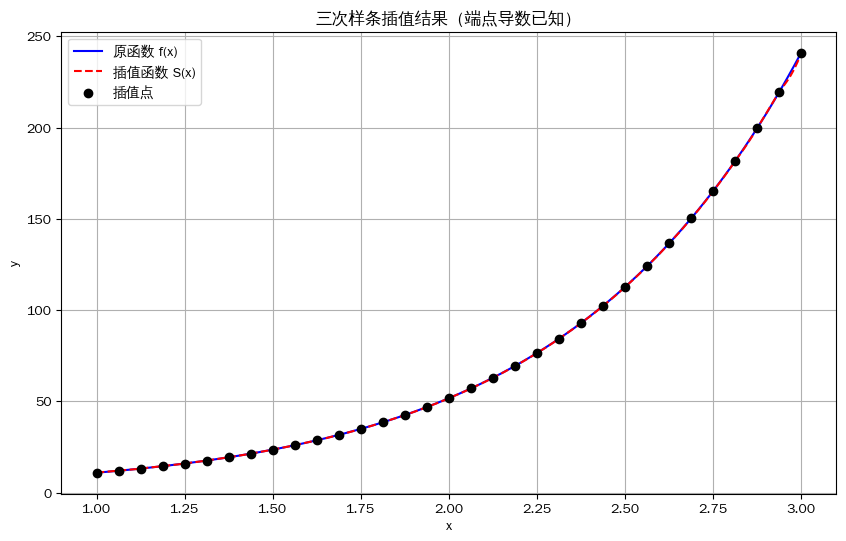

f_dao(1) = 24.464536
S_dao(1) = 24.464536
f_dao(3) = 542.309497
S_dao(3) = 542.309497


In [17]:
# 设置中文字体，使用系统中可用的 WenQuanYi Zen Hei
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘图
plt.figure(figsize=(10, 6))
x = np.linspace(1, 3, 200)
y_f = f(x)
y_S = np.array([S(x_i) for x_i in x])

plt.plot(x, y_f, label='原函数 f(x)', color='blue')
plt.plot(x, y_S, label='插值函数 S(x)', color='red', linestyle='--')
plt.scatter(x_jiedian, value_jiedian, color='black', zorder=5, label='插值点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('三次样条插值结果（端点导数已知）')
plt.legend()
plt.grid(True)
plt.savefig('sanciyangtiao.png')
plt.show()

# 输出端点导数
print(f"f_dao(1) = {f_dao_0:.6f}")
print(f"S_dao(1) = {S_dao_1:.6f}")
print(f"f_dao(3) = {f_dao_n:.6f}")
print(f"S_dao(3) = {S_dao_3:.6f}")